In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from pathlib import Path
from itertools import combinations
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler
from scipy.linalg import subspace_angles
import numpy as np
import matplotlib.pyplot as plt
import gc

Loading the data

In [ ]:
base_dir = Path("/content/drive/My Drive/Group 10 Project/data/processed_subject_epochs")
bad_subjects = {"S088", "S092", "S100"}
CONDITIONS   = ["left_fist", "right_fist", "both_fists", "both_feet", "rest"]
K            = 27

subject_dirs = sorted([
    d for d in base_dir.iterdir()
    if d.is_dir() and d.name.startswith("S")
])

print(f"Total subjects found: {len(subject_dirs)}")
print(f"Bad subjects skipped: {bad_subjects}")

Total subjects found: 109
Bad subjects skipped: {'S092', 'S100', 'S088'}


This step takes time: flattening epoch and running incremental PCA

In [ ]:
ipca_models = {cond: IncrementalPCA(n_components=K)
               for cond in CONDITIONS}

kept   = []
failed = []

for subj_dir in subject_dirs:

    if subj_dir.name in bad_subjects:
        continue

    npz_path = subj_dir / "epochs.npz"
    if not npz_path.exists():
        continue

    try:
        with np.load(npz_path) as npz:
            for cond in CONDITIONS:
                if cond not in npz.files:
                    continue

                epochs = npz[cond]  # (n_epochs, 64, 401)

                # Flatten each epoch into one long vector
                X = epochs.reshape(epochs.shape[0], -1).astype(np.float32)

                # Standardize
                X = StandardScaler().fit_transform(X)

                # Update PCA — processes this batch without storing everything in memory
                ipca_models[cond].partial_fit(X)

                del X, epochs
                gc.collect()

        kept.append(subj_dir.name)
        print(f"  Done: {subj_dir.name}")

    except Exception as e:
        failed.append(subj_dir.name)
        print(f"  Failed: {subj_dir.name} — {e}")

print(f"\nSubjects processed: {len(kept)}")
print(f"Subjects failed:    {len(failed)}")

  Done: S001
  Done: S002
  Done: S003
  Done: S004
  Done: S005
  Done: S006
  Done: S007
  Done: S008
  Done: S009
  Done: S010
  Done: S011
  Done: S012
  Done: S013
  Done: S014
  Done: S015
  Done: S016
  Done: S017
  Done: S018
  Done: S019
  Done: S020
  Done: S021
  Done: S022
  Done: S023
  Done: S024
  Done: S025
  Done: S026
  Done: S027
  Done: S028
  Done: S029
  Done: S030
  Done: S031
  Done: S032
  Done: S033
  Done: S034
  Done: S035
  Done: S036
  Done: S037
  Done: S038
  Done: S039
  Done: S040
  Done: S041
  Done: S042
  Done: S043
  Done: S044
  Done: S045
  Done: S046
  Done: S047
  Done: S048
  Done: S049
  Done: S050
  Done: S051
  Done: S052
  Done: S053
  Done: S054
  Done: S055
  Done: S056
  Done: S057
  Done: S058
  Done: S059
  Done: S060
  Done: S061
  Done: S062
  Done: S063
  Done: S064
  Done: S065
  Done: S066
  Done: S067
  Done: S068
  Done: S069
  Done: S070
  Done: S071
  Done: S072
  Done: S073
  Done: S074
  Done: S075
  Done: S076
  Done: S077

Scree plots

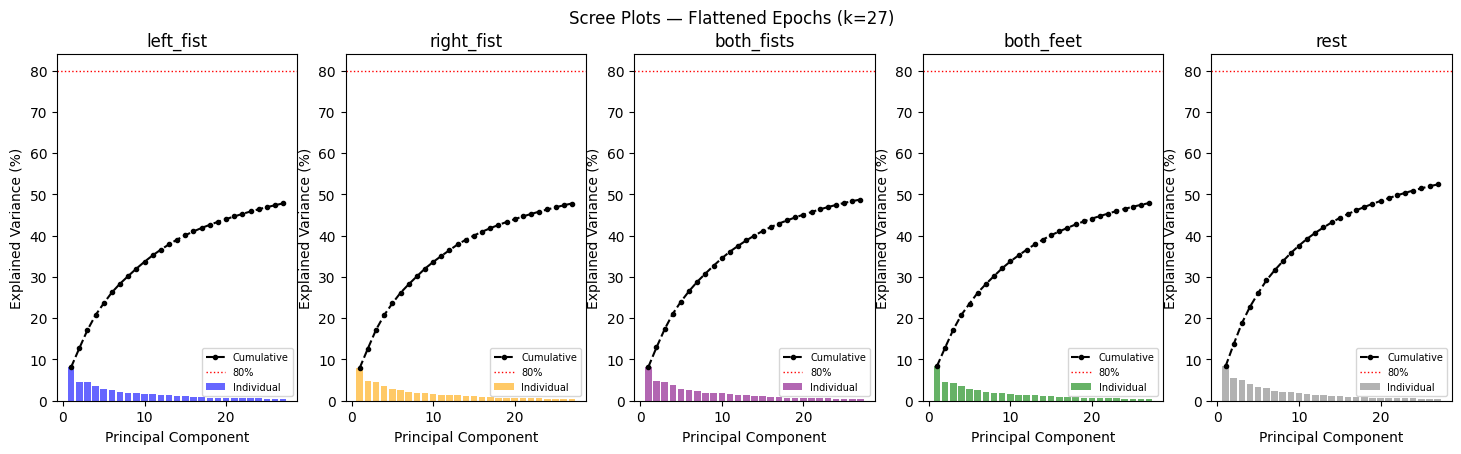

In [ ]:
colors = ["blue", "orange", "purple", "green", "gray"]
fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))

for ax, cond, color in zip(axes, CONDITIONS, colors):
    ev     = ipca_models[cond].explained_variance_ratio_ * 100
    cumvar = np.cumsum(ev)
    comps  = np.arange(1, len(ev) + 1)

    ax.bar(comps, ev, color=color, alpha=0.6, label="Individual")
    ax.plot(comps, cumvar, "k--o", ms=3, label="Cumulative")
    ax.axhline(80, color="red", linestyle=":", linewidth=1, label="80%")
    ax.set_title(cond)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance (%)")
    ax.legend(fontsize=7)

plt.suptitle(f"Scree Plots — Flattened Epochs (k={K})")
plt.show()

Saving the data

In [ ]:
save_path = "/content/drive/My Drive/ipca_flattened_components.npz"

save_dict = {}
for cond in CONDITIONS:
    save_dict[cond]          = ipca_models[cond].components_
    save_dict[f"{cond}_ev"]  = ipca_models[cond].explained_variance_ratio_
    save_dict[f"{cond}_var"] = ipca_models[cond].explained_variance_

np.savez(save_path, **save_dict)
print(f"Saved to {save_path}")

Saved to /content/drive/My Drive/ipca_flattened_components.npz


Reloading the data once it has been saved

In [ ]:
loaded = np.load(save_path)

ipca_models = {
    cond: type('obj', (object,), {
        'components_':               loaded[cond],
        'explained_variance_ratio_': loaded[f"{cond}_ev"],
        'explained_variance_':       loaded[f"{cond}_var"],
    })()
    for cond in CONDITIONS
}


Subspace angle analysis

left_fist vs right_fist: 18.7°
left_fist vs both_fists: 19.4°
left_fist vs both_feet: 20.0°
left_fist vs rest: 16.4°
right_fist vs both_fists: 19.9°
right_fist vs both_feet: 19.7°
right_fist vs rest: 16.8°
both_fists vs both_feet: 20.7°
both_fists vs rest: 15.9°
both_feet vs rest: 17.3°


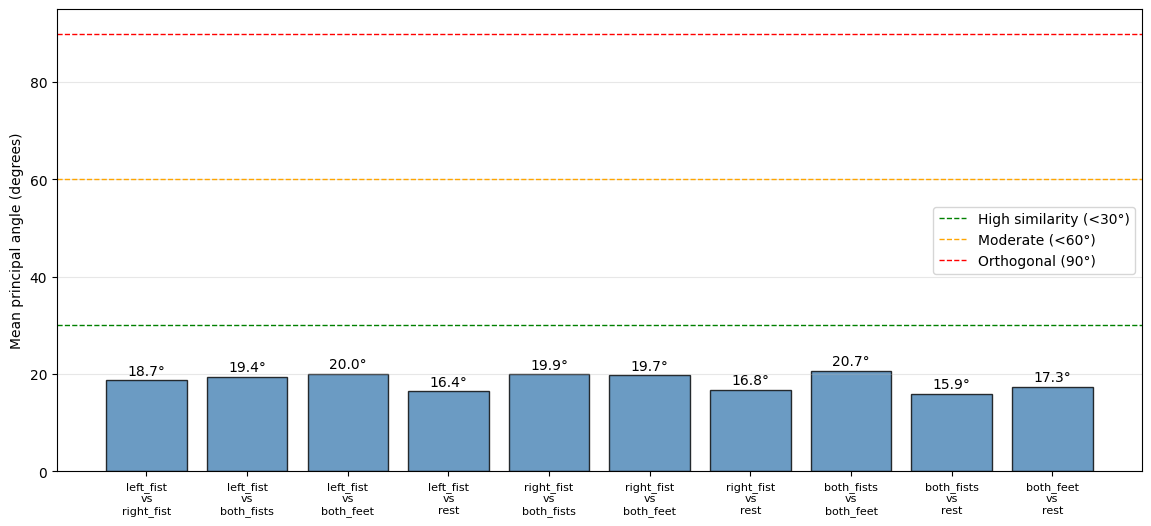

In [ ]:
pair_labels = []
mean_angles = []

for cond_a, cond_b in combinations(CONDITIONS, 2):
    U_a = ipca_models[cond_a].components_[:K].T
    U_b = ipca_models[cond_b].components_[:K].T
    ang = np.degrees(subspace_angles(U_a, U_b)).mean()

    pair_labels.append(f"{cond_a}\nvs\n{cond_b}")
    mean_angles.append(ang)
    print(f"{cond_a} vs {cond_b}: {ang:.1f}°")

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(np.arange(len(pair_labels)), mean_angles,
              color="steelblue", alpha=0.8, edgecolor="black")
ax.set_xticks(np.arange(len(pair_labels)))
ax.set_xticklabels(pair_labels, fontsize=8)
ax.set_ylabel("Mean principal angle (degrees)")
ax.axhline(30, color="green",  linestyle="--", linewidth=1, label="High similarity (<30°)")
ax.axhline(60, color="orange", linestyle="--", linewidth=1, label="Moderate (<60°)")
ax.axhline(90, color="red",    linestyle="--", linewidth=1, label="Orthogonal (90°)")
ax.set_ylim(0, 95)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, mean_angles):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.1f}°", ha="center", va="bottom")
plt.show()

Loading the data from the time averaging and comparing with flattened epoch

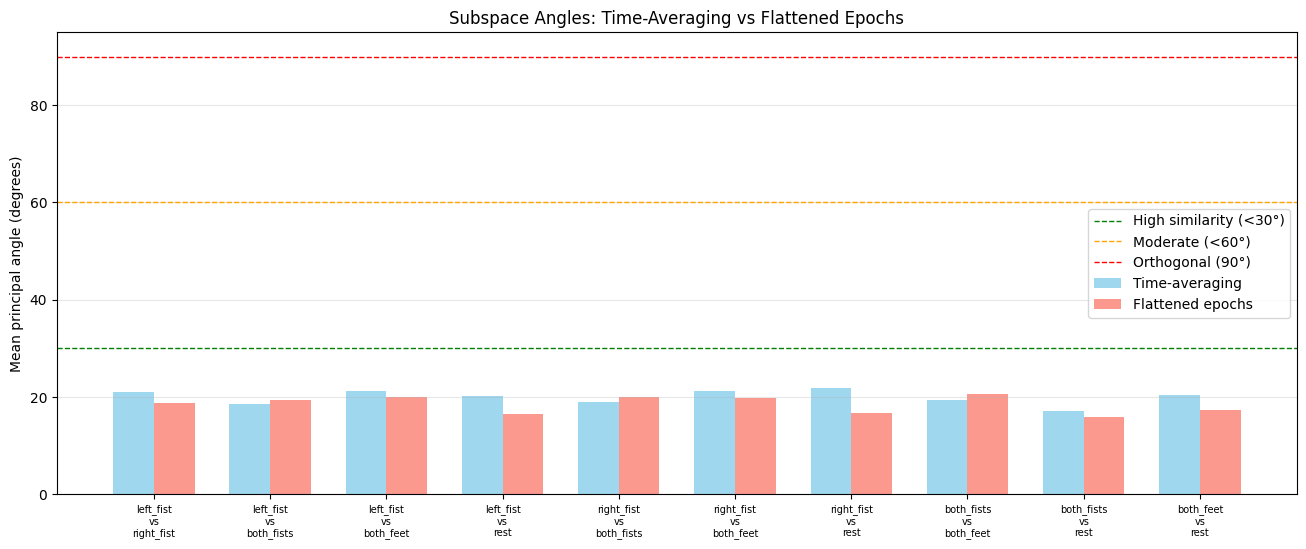


Mean angle — Time-averaging: 20.0°
Mean angle — Flattened:      18.5°


In [ ]:
timeAvg_path = "/content/drive/My Drive/pca_timeavg_components.npz"

try:
    timeAvg_loaded  = np.load(timeAvg_path)
    timeAvg_models  = {cond: type('obj', (object,),
                  {'components_': timeAvg_loaded[cond]})()
                  for cond in CONDITIONS}

    pair_labels_c  = []
    angles_flat    = []
    angles_timeavg = []

    for cond_a, cond_b in combinations(CONDITIONS, 2):
        # Flattened angles
        U_a = ipca_models[cond_a].components_[:K].T
        U_b = ipca_models[cond_b].components_[:K].T
        ang_flat = np.degrees(subspace_angles(U_a, U_b)).mean()

        # Time-averaged angles
        U_a_t = timeAvg_models[cond_a].components_[:K].T
        U_b_t = timeAvg_models[cond_b].components_[:K].T
        ang_ta = np.degrees(subspace_angles(U_a_t, U_b_t)).mean()

        pair_labels_c.append(f"{cond_a}\nvs\n{cond_b}")
        angles_flat.append(ang_flat)
        angles_timeavg.append(ang_ta)

    # Plot comparison
    x = np.arange(len(pair_labels_c))
    w = 0.35

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - w/2, angles_timeavg, w, label="Time-averaging",
           color="skyblue",  alpha=0.8)
    ax.bar(x + w/2, angles_flat,    w, label="Flattened epochs",
           color="salmon", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels_c, fontsize=7)
    ax.set_ylabel("Mean principal angle (degrees)")
    ax.set_title("Subspace Angles: Time-Averaging vs Flattened Epochs")
    ax.axhline(30, color="green",  linestyle="--", linewidth=1, label="High similarity (<30°)")
    ax.axhline(60, color="orange", linestyle="--", linewidth=1, label="Moderate (<60°)")
    ax.axhline(90, color="red",    linestyle="--", linewidth=1, label="Orthogonal (90°)")
    ax.set_ylim(0, 95)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.show()

    print(f"\nMean angle — Time-averaging: {np.mean(angles_timeavg):.1f}°")
    print(f"Mean angle — Flattened:      {np.mean(angles_flat):.1f}°")
except FileNotFoundError:
    print("Time-averaged components not found.")
